In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms, datasets, models
import os

数据加载与预处理

In [2]:
data_dir = 'D:\\yysls\\bird_dataset_split' 

# 数据增强与归一化 (仅对训练集进行增强)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 创建数据集和数据加载器
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']} # 假设你已按文档比例创建了train, val, test子文件夹

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=16,
                                               shuffle=(x == 'train'), num_workers=4)
               for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"Dataset size: {dataset_sizes}")
print(f"Number of categories: {num_classes}")

Dataset size: {'train': 7048, 'val': 2323, 'test': 2417}
Number of categories: 200


数据增强结果可视化

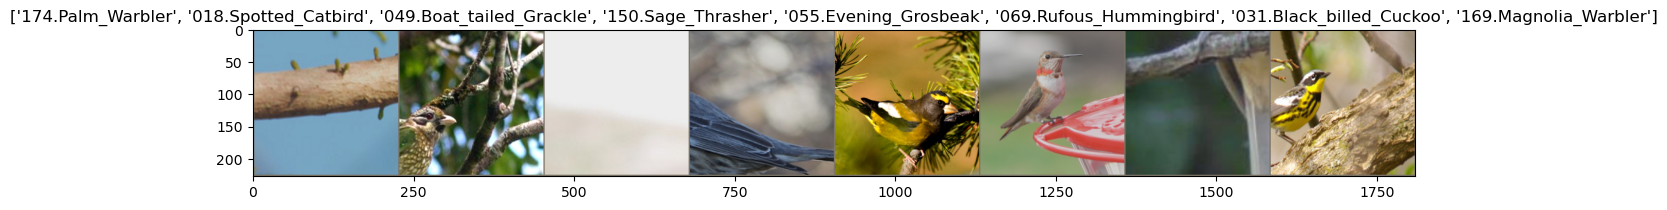

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(inp, title=None):
    """展示 Tensor 图像"""
    inp = inp.numpy().transpose((1, 2, 0))
    # 反归一化：与你定义的 Normalize 参数对应
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # 限制在 0-1 之间
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# 获取一批训练数据
inputs, classes = next(iter(dataloaders['train']))

# 将这批图片做成网格
out = torchvision.utils.make_grid(inputs[:8]) # 只展示前8张

plt.figure(figsize=(15, 10))
imshow(out, title=[class_names[x] for x in classes[:8]])
plt.show()

构建迁移学习模型

In [4]:
from torchsummary import summary

def initialize_model(num_classes):
    """
    初始化torchvision的EfficientNetV2-S模型，并替换分类头。
    """
    # 加载在ImageNet-1k上预训练的EfficientNetV2-S（torchvision官方版）
    model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
    
    # 获取分类器的输入特征数（对于EfficientNetV2-S是1280）
    num_ftrs = model.classifier[1].in_features
    
    # 替换整个分类器（包括Dropout层和Linear层）
    # 保持相同的Dropout率(0.2)，只修改输出维度
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(num_ftrs, num_classes)
    )
    
    return model, num_ftrs

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, num_ftrs = initialize_model(num_classes)
model = model.to(device)
print(f"The model has been loaded onto the device: {device}")
print(f"Feature Dimension: {num_ftrs}")

# 假设输入是 224x224 的 3 通道图片
summary(model, input_size=(3, 224, 224))

The model has been loaded onto the device: cuda:0
Feature Dimension: 1280
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         

搭建训练函数

In [5]:
import copy

def train_model(model, dataloaders, criterion, optimizer, scheduler, 
                num_epochs=300, patience=30):
    """
    含早停机制和全调度器兼容的训练函数
    """
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # 早停相关变量
    early_stop_counter = 0 
    stop_training = False

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        if stop_training:
            break
            
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 存储历史记录
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # --- 调度器更新逻辑修复 ---
                if scheduler:
                    if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler.step(epoch_acc)
                    else:
                        scheduler.step() # 兼容 StepLR, MultiStepLR 等

                # --- 早停与模型保存逻辑 ---
                if epoch_acc > best_acc:
                    print(f"Performance improvement detected ({best_acc:.4f} -> {epoch_acc:.4f})，save Model...")
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    # 重置早停计数器
                    early_stop_counter = 0
                    torch.save(model.state_dict(), 'best_model_checkpoint.pth')
                else:
                    if phase == 'val':
                        early_stop_counter += 1
                        print(f"Validation set performance did not improve; early stopping count: {early_stop_counter}/{patience}")
                        if early_stop_counter >= patience:
                            print("The early stop mechanism is triggered, and training is stopped.")
                            stop_training = True

        print()

    print(f'Training complete! Best validation set accuracy: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, best_acc, history

第一阶段：冻结主干，训练分类头

In [6]:
print("=" * 30)
print("Phase 1: Freeze the feature extractor and train only the classification head.")
print("=" * 30)

# 1. 冻结参数
for name, param in model.named_parameters():
    if 'classifier' not in name: 
        param.requires_grad = False

# 2. 收集待更新参数
params_to_update = [p for p in model.parameters() if p.requires_grad]

# 3. 定义优化器和调度器
optimizer_phase1 = optim.Adam(params_to_update, lr=0.001)
criterion = nn.CrossEntropyLoss()
exp_lr_scheduler_phase1 = optim.lr_scheduler.StepLR(optimizer_phase1, step_size=30, gamma=0.1)

# 4. 调用函数：注意这里接收三个返回值
model, phase1_best_acc, phase1_history = train_model(
    model, dataloaders, criterion, optimizer_phase1,
    exp_lr_scheduler_phase1, num_epochs=50
)

Phase 1: Freeze the feature extractor and train only the classification head.
Epoch 0/49
----------
train Loss: 4.1172 Acc: 0.1670
val Loss: 39.8958 Acc: 0.3698
Performance improvement detected (0.0000 -> 0.3698)，save Model...

Epoch 1/49
----------
train Loss: 2.8262 Acc: 0.3621
val Loss: 2.2655 Acc: 0.4546
Performance improvement detected (0.3698 -> 0.4546)，save Model...

Epoch 2/49
----------
train Loss: 2.4750 Acc: 0.4232
val Loss: 50.9503 Acc: 0.4770
Performance improvement detected (0.4546 -> 0.4770)，save Model...

Epoch 3/49
----------
train Loss: 2.2587 Acc: 0.4539
val Loss: 231.6184 Acc: 0.4929
Performance improvement detected (0.4770 -> 0.4929)，save Model...

Epoch 4/49
----------
train Loss: 2.1256 Acc: 0.4835
val Loss: 114.3426 Acc: 0.5045
Performance improvement detected (0.4929 -> 0.5045)，save Model...

Epoch 5/49
----------
train Loss: 2.0188 Acc: 0.4874
val Loss: 1.7427 Acc: 0.5213
Performance improvement detected (0.5045 -> 0.5213)，save Model...

Epoch 6/49
----------


第二阶段：解冻部分/全部层，进行端到端微调

In [7]:
print("=" * 30)
print("Phase 2: Unfreeze the entire network and perform end-to-end fine-tuning.")
print("=" * 30)

# 1. 解冻所有参数
for param in model.parameters():
    param.requires_grad = True

# 2. 重新定义优化器，使用更小的学习率 (通常为第一阶段的 1/10)
optimizer_phase2 = optim.Adam(model.parameters(), lr=1e-5) 

# 3. 定义 ReduceLROnPlateau 调度器
# 注意：mode='max' 是因为我们监控的是验证集准确率 (val_acc)
scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2, mode='max', factor=0.1, patience=10, verbose=True
)

# 4. 执行训练并接收三个返回值 
model, phase2_best_acc, phase2_history = train_model(
    model, 
    dataloaders, 
    criterion, 
    optimizer_phase2, 
    scheduler_phase2, 
    num_epochs=250)

Phase 2: Unfreeze the entire network and perform end-to-end fine-tuning.
Epoch 0/249
----------


d:\Anaconda\envs\pytorch_gpu\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


train Loss: 1.2347 Acc: 0.6734
val Loss: 1.0616 Acc: 0.6995
Performance improvement detected (0.0000 -> 0.6995)，save Model...

Epoch 1/249
----------
train Loss: 1.1035 Acc: 0.7117
val Loss: 0.9540 Acc: 0.7310
Performance improvement detected (0.6995 -> 0.7310)，save Model...

Epoch 2/249
----------
train Loss: 0.9890 Acc: 0.7371
val Loss: 0.8823 Acc: 0.7495
Performance improvement detected (0.7310 -> 0.7495)，save Model...

Epoch 3/249
----------
train Loss: 0.9263 Acc: 0.7619
val Loss: 0.8308 Acc: 0.7624
Performance improvement detected (0.7495 -> 0.7624)，save Model...

Epoch 4/249
----------
train Loss: 0.8911 Acc: 0.7675
val Loss: 0.7895 Acc: 0.7800
Performance improvement detected (0.7624 -> 0.7800)，save Model...

Epoch 5/249
----------
train Loss: 0.8416 Acc: 0.7748
val Loss: 0.7783 Acc: 0.7779
Validation set performance did not improve; early stopping count: 1/30

Epoch 6/249
----------
train Loss: 0.7899 Acc: 0.7887
val Loss: 0.7624 Acc: 0.7843
Performance improvement detected (0

训练过程绘图

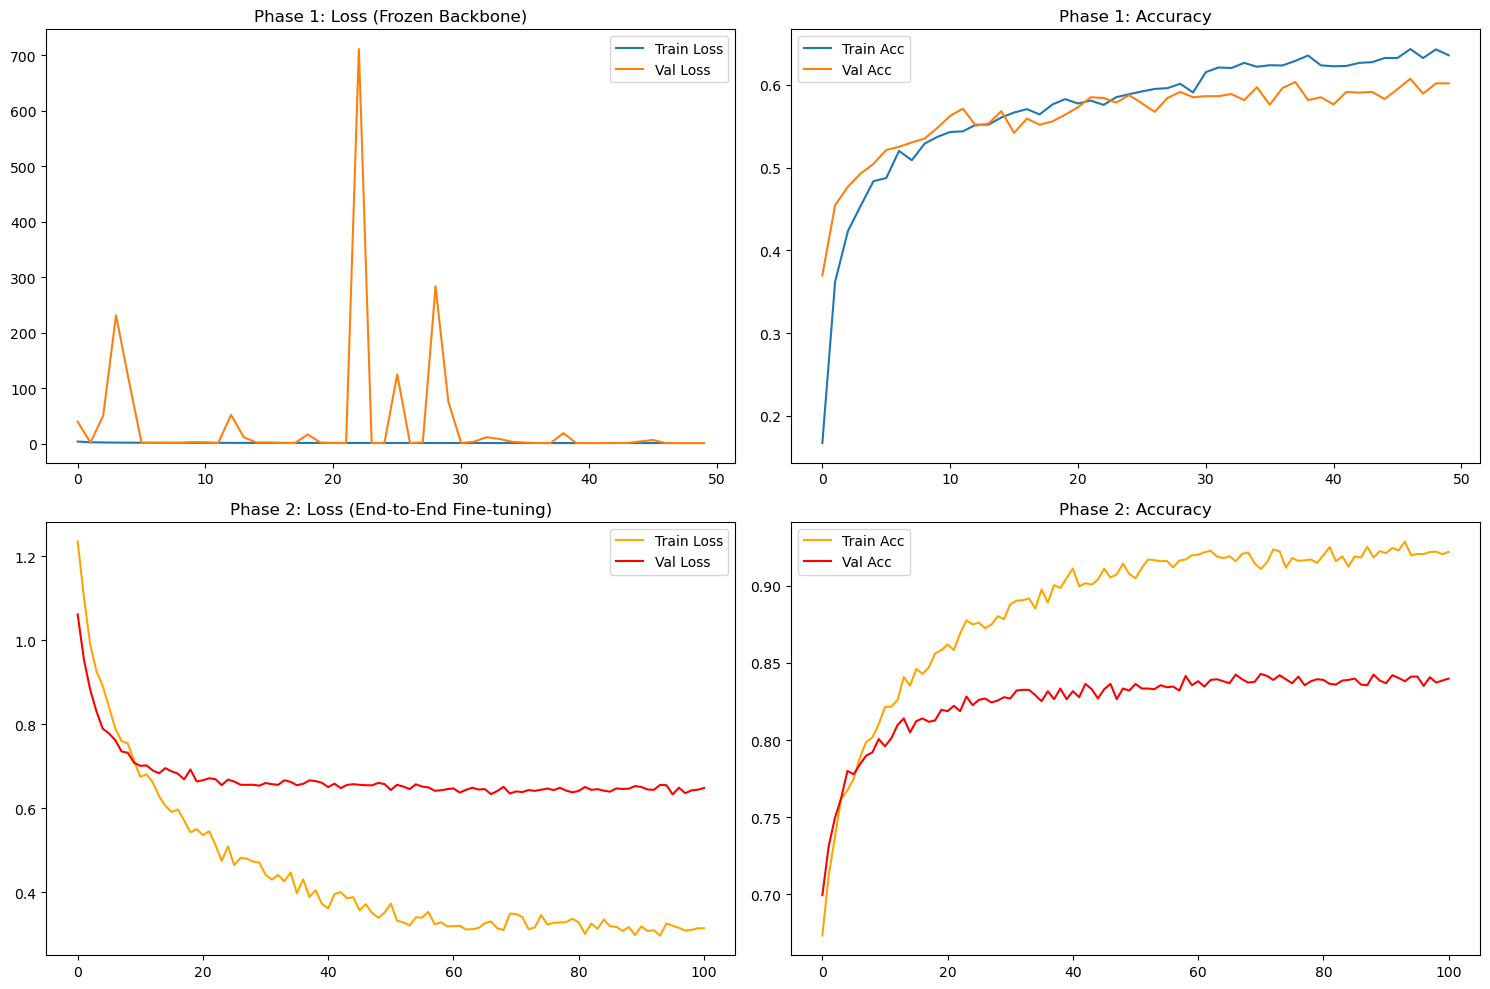

In [8]:
import matplotlib.pyplot as plt

def plot_full_training(h1, h2):
    """
    h1: 第一阶段 history
    h2: 第二阶段 history
    """
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # --- 第一阶段 Loss ---
    axs[0, 0].plot(h1['train_loss'], label='Train Loss')
    axs[0, 0].plot(h1['val_loss'], label='Val Loss')
    axs[0, 0].set_title('Phase 1: Loss (Frozen Backbone)')
    axs[0, 0].legend()

    # --- 第一阶段 Acc ---
    axs[0, 1].plot(h1['train_acc'], label='Train Acc')
    axs[0, 1].plot(h1['val_acc'], label='Val Acc')
    axs[0, 1].set_title('Phase 1: Accuracy')
    axs[0, 1].legend()

    # --- 第二阶段 Loss ---
    axs[1, 0].plot(h2['train_loss'], label='Train Loss', color='orange')
    axs[1, 0].plot(h2['val_loss'], label='Val Loss', color='red')
    axs[1, 0].set_title('Phase 2: Loss (End-to-End Fine-tuning)')
    axs[1, 0].legend()

    # --- 第二阶段 Acc ---
    axs[1, 1].plot(h2['train_acc'], label='Train Acc', color='orange')
    axs[1, 1].plot(h2['val_acc'], label='Val Acc', color='red')
    axs[1, 1].set_title('Phase 2: Accuracy')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

# 训练全部结束后调用
plot_full_training(phase1_history, phase2_history)

在测试集上进行最终评估

In [9]:
print("=" * 30)
print("Final stage: Evaluate the model on the test set")
print("=" * 30)

model.eval()
test_corrects = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        test_corrects += torch.sum(preds == labels.data)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_corrects.double() / dataset_sizes['test']
print(f'测试集 Top-1 准确率: {test_acc:.4f}')


Final stage: Evaluate the model on the test set
测试集 Top-1 准确率: 0.8250


混淆矩阵

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

def plot_confusion_matrix(model, dataloader, class_names, save_name="cm.png"):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("正在计算混淆矩阵...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 计算矩阵
    cm = confusion_matrix(all_labels, all_preds)
    
    # 绘图
    plt.figure(figsize=(max(10, len(class_names)//2), max(8, len(class_names)//2)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.savefig(save_name)
    plt.show()

    # 打印详细报表 (包含 Precision, Recall, F1-score)
    print("\n分类详细报表:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# 建议在 phase2 训练结束后运行
plot_confusion_matrix(model, dataloaders['test'], class_names)

正在计算混淆矩阵...



分类详细报表:
                                    precision    recall  f1-score   support

        001.Black_footed_Albatross       0.79      0.92      0.85        12
              002.Laysan_Albatross       0.80      1.00      0.89        12
               003.Sooty_Albatross       0.85      0.85      0.85        13
             004.Groove_billed_Ani       1.00      0.92      0.96        12
                005.Crested_Auklet       1.00      0.80      0.89        10
                  006.Least_Auklet       1.00      1.00      1.00         9
               007.Parakeet_Auklet       0.86      1.00      0.92        12
             008.Rhinoceros_Auklet       0.77      0.91      0.83        11
              009.Brewer_Blackbird       0.71      0.38      0.50        13
          010.Red_winged_Blackbird       0.79      0.92      0.85        12
               011.Rusty_Blackbird       0.77      0.83      0.80        12
       012.Yellow_headed_Blackbird       1.00      0.92      0.96        12
  